# Modified Rates

In [1]:
import pynucastro as pyna

First create the exact and approximate network. We will use the CNOII cycle.

In [2]:
rl = pyna.ReacLibLibrary()
CNOII_lib = rl.linking_nuclei(["p", "he4", "n15", "o16", "f17", 
                             "o17", "n14", "o15"], with_reverse=False)
CNOII = pyna.PythonNetwork(libraries=[CNOII_lib])

In [3]:
CNOII

O15 ⟶ N15 + e⁺ + 𝜈
F17 ⟶ O17 + e⁺ + 𝜈
N14 + p ⟶ O15 + 𝛾
N15 + p ⟶ O16 + 𝛾
O16 + p ⟶ F17 + 𝛾
O17 + p ⟶ He4 + N14

Now create the approximate version

$$
    {}^{16}\mathrm{O} (p, \gamma) {}^{17}\mathrm{F} (, e^+ \nu) {}^{17}\mathrm{O} (p,\alpha) {}^{14}\mathrm{N}  
    \rightarrow {}^{16}\mathrm{O} (pp, \alpha) {}^{14}\mathrm{N}
$$

In [4]:
O16p_gF17 = CNOII.get_rate_by_name("o16(p,g)f17")
O16pp_aN14 = pyna.ModifiedRate(O16p_gF17,
                               new_reactants=["p", "o16"],
                               new_products=["n14", "he4"],
                               stoichiometry={pyna.Nucleus("p"): 2})

In [5]:
approx_rates = [O16pp_aN14]
approx_rates.append(CNOII.get_rate_by_name("n15(p,g)o16"))
approx_rates.append(CNOII.get_rate_by_name("n14(p,g)o15"))
approx_rates.append(CNOII.get_rate_by_name("o15(,e)n15"))

approx_CNOII = pyna.PythonNetwork(rates=approx_rates)

In [6]:
approx_CNOII

O16 + p + p ⟶ N14 + He4 + e⁺ + 𝜈
N15 + p ⟶ O16 + 𝛾
N14 + p ⟶ O15 + 𝛾
O15 ⟶ N15 + e⁺ + 𝜈

Now let's integrate the two networks under the same thermodynamic condition. We will use a solar-like initial composition where we set $X({}^{1}\mathrm{H}) = 0.7$,  $X({}^{4}\mathrm{He}) = 0.3 - Z$, where $Z$ is the metallicity. We use a massfraction of $0.005$ for all metals (elements other than ${}^{1}\mathrm{H}$ or ${}^{4}\mathrm{He}$), and the sum of the massfraction for all metals determines the metallicity.

In [7]:
T = 2e7
rho = 1e2
tmax = 1e32

In [8]:
comp = pyna.Composition(CNOII.unique_nuclei, small=0.0)
comp.set_all(0.05)
comp.X[pyna.Nucleus("H1")] = 0.7
comp.X[pyna.Nucleus("He4")] = 0.3 - 0.005*(len(CNOII.unique_nuclei)-2)
Y0 = comp.get_molar_array()
sol = CNOII.integrate_network(tmax, rho, T, Y0, rtol=1.e-8, atol=1.e-10)

In [9]:
approx_comp = pyna.Composition(approx_CNOII.unique_nuclei, small=0.0, init="solar")
approx_comp.set_all(0.05)
approx_comp.X[pyna.Nucleus("H1")] = 0.7
approx_comp.X[pyna.Nucleus("He4")] = 0.3 - 0.005*(len(approx_CNOII.unique_nuclei)-2)
approx_Y0 = approx_comp.get_molar_array()
sol_approx = approx_CNOII.integrate_network(tmax, rho, T, approx_Y0, rtol=1.e-8, atol=1.e-10)

Now let's make a plot see how they compare.

In [12]:
import matplotlib.pyplot as plt
import numpy as np

SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 20
MAJOR_TICK_SIZE = 5
MINOR_TICK_SIZE = 3

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('xtick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('xtick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rc('ytick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('ytick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rcParams.update({'lines.linewidth': 2})

/tmp/ipykernel_798671/930082491.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


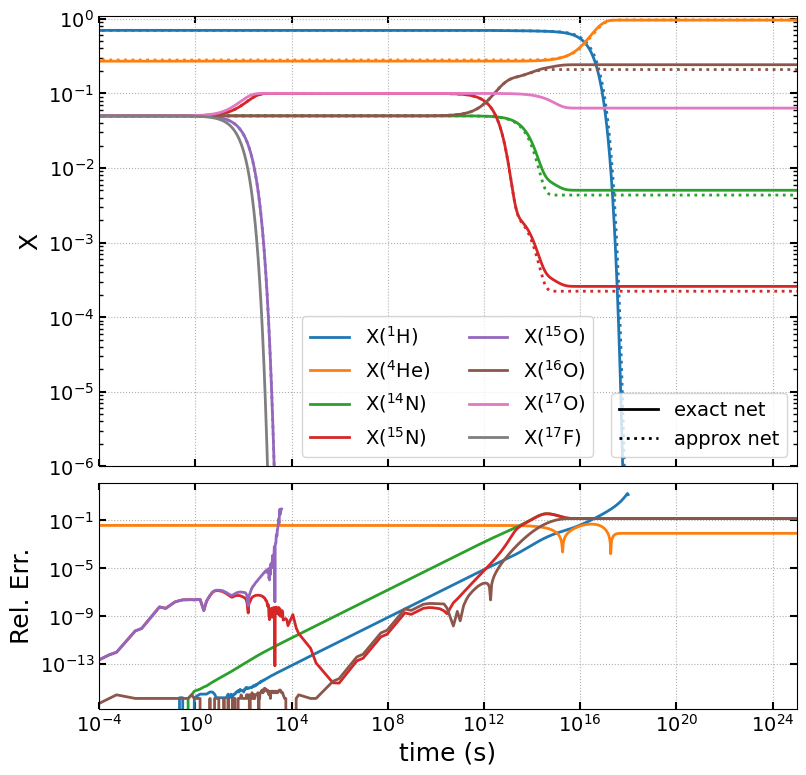

In [14]:
fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(9, 9), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

# Top Panel
for i, nuc in enumerate(sol.unique_nuclei):
    ax.loglog(sol.t, sol.X[i, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}")
    try:
        idx = sol_approx.unique_nuclei.index(nuc)
        ax.loglog(sol_approx.t, sol_approx.X[idx, :],
                  linestyle=":", color=f"C{i}")
    except:
        continue
        
ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-4, 1e25)
ax.set_ylabel("X")
ax.grid(ls=":")

# Add species legend
species_legend = ax.legend(loc="lower center", ncol=2)
ax.add_artist(species_legend)

# Add line legend
style_legend = [
    plt.Line2D([0], [0], color="k", linestyle="-", label="exact net"),
    plt.Line2D([0], [0], color="k", linestyle=":", label="approx net"),
]
ax.legend(handles=style_legend, loc="lower right")

# Bot panel for plotting error between common species
X_FLOOR = 1.e-10
for i, nuc in enumerate(sol_approx.unique_nuclei):
    idx = sol.unique_nuclei.index(nuc)
    X_ref = sol.X[idx, :]
    X_approx = sol_approx.X_at(sol.t)[i, :]

    # Only compute error for X greater than absolute tolerance of the integrator
    invalid = X_ref < X_FLOOR
    rel_err = np.abs(X_approx - X_ref) / X_ref
    rel_err[invalid] = np.nan
    
    ax_err.loglog(sol.t, rel_err,
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{idx}", linewidth=2)

ax_err.set_xlabel("time (s)")
ax_err.set_ylabel("Rel. Err.")
ax_err.grid(ls=":")

for a in (ax, ax_err):
    a.minorticks_on()
    a.tick_params(top=True, bottom=True,
                  left=True, right=True,
                  direction="in", which="both")

fig.tight_layout()
fig.savefig("modified-rate-integrate.pdf", bbox_inches="tight")